<a href="https://colab.research.google.com/github/JSEFERINO/Analisis-de-Datos-con-Python-2020/blob/master/LAB_10_ESTADISTICA_II_JULIAN_CAMACHO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LABORATORIO 10**
# **ESTADISTICA INFERENCIAL**
## **JULIAN ALFONSO CAMACHO BERTEL**
> Email: julcamacho@utb.edu.co

> Celular: 3185218349

> T00059816

# **Librerias para Trabar en R**

In [ ]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [Contexto 1: Brecha salarial por género en el sector financiero](#T1)
## **2.** [Contexto 2: Evaluación de impacto de programa social](#T2)

## **3.** [Contexto 3: Comparación de metodologías educativas](#T3)

## **4.** [Contexto 4: Efecto de una campaña de salud pública](#T4)

## **5.** [Contexto 5: Intención de voto en dos ciudades](#T5)

## **6.** [Contexto 6: Control de calidad en producción agrícola](#T6)

## **7.** [Contexto 7: Comparación de volatilidad en mercados financieros](#T7)





[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Contexto 1: Brecha salarial por género en el sector financiero**


------------------------------
ANÁLISIS PARA: Julian Camacho
------------------------------
Diferencia de medias: 0.60
Error Estándar: 0.1329
Valor Z crítico: 1.960
Intervalo de Confianza (95%): (0.34, 0.86)
------------------------------


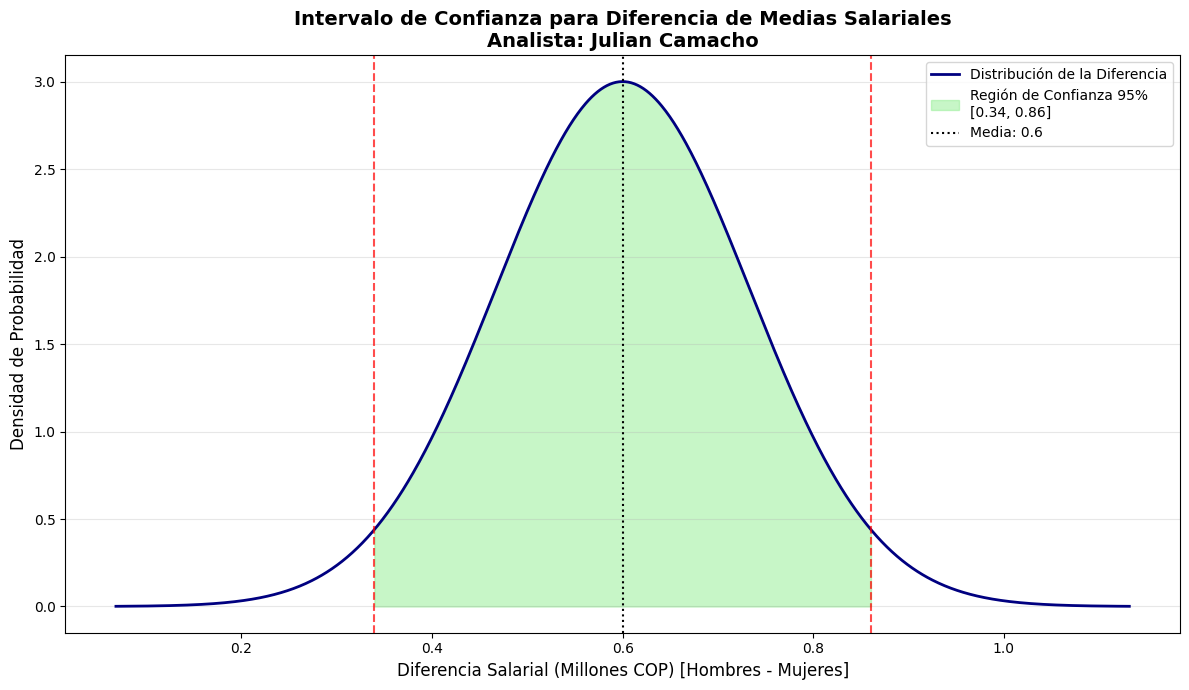

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Definición de datos del problema
n_h, media_h, std_h = 150, 4.8, 1.2
n_m, media_m, std_m = 150, 4.2, 1.1
confianza = 0.95
nombre_estudiante = "Julian Camacho"

# 2. Cálculos Estadísticos
diff_muestral = media_h - media_m
# Error estándar para muestras independientes
error_estandar = np.sqrt((std_h**2 / n_h) + (std_m**2 / n_m))

# Valor crítico Z para 95% (bilateral)
z_critico = norm.ppf(1 - (1 - confianza) / 2)
margen_error = z_critico * error_estandar

# Límites del Intervalo de Confianza (IC)
ic_inferior = diff_muestral - margen_error
ic_superior = diff_muestral + margen_error

# 3. Impresión de resultados técnicos
print("-" * 30)
print(f"ANÁLISIS PARA: {nombre_estudiante}")
print("-" * 30)
print(f"Diferencia de medias: {diff_muestral:.2f}")
print(f"Error Estándar: {error_estandar:.4f}")
print(f"Valor Z crítico: {z_critico:.3f}")
print(f"Intervalo de Confianza (95%): ({ic_inferior:.2f}, {ic_superior:.2f})")
print("-" * 30)

# 4. Generación del Gráfico
plt.figure(figsize=(12, 7))

# Crear eje X para la distribución normal (basada en la diferencia)
x = np.linspace(diff_muestral - 4*error_estandar, diff_muestral + 4*error_estandar, 1000)
y = norm.pdf(x, diff_muestral, error_estandar)

# Dibujar la curva
plt.plot(x, y, color='navy', lw=2, label='Distribución de la Diferencia')

# Sombrear la Región del Intervalo de Confianza
x_fill = np.linspace(ic_inferior, ic_superior, 500)
y_fill = norm.pdf(x_fill, diff_muestral, error_estandar)
plt.fill_between(x_fill, y_fill, color='lightgreen', alpha=0.5,
                 label=f'Región de Confianza 95%\n[{ic_inferior:.2f}, {ic_superior:.2f}]')

# Líneas verticales de los límites
plt.axvline(ic_inferior, color='red', linestyle='--', alpha=0.7)
plt.axvline(ic_superior, color='red', linestyle='--', alpha=0.7)
plt.axvline(diff_muestral, color='black', linestyle=':', label=f'Media: {diff_muestral:.1f}')

# Personalización y Firma
plt.title(f'Intervalo de Confianza para Diferencia de Medias Salariales\nAnalista: {nombre_estudiante}',
          fontsize=14, fontweight='bold')
plt.xlabel('Diferencia Salarial (Millones COP) [Hombres - Mujeres]', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------------------
RESULTADOS DEL ANÁLISIS
Autor: Julian Camacho 
------------------------------------------
Diferencia de medias: 0.6 
Error estándar: 0.1329 
Intervalo de Confianza (95%): [ 0.339 , 0.861 ]
------------------------------------------


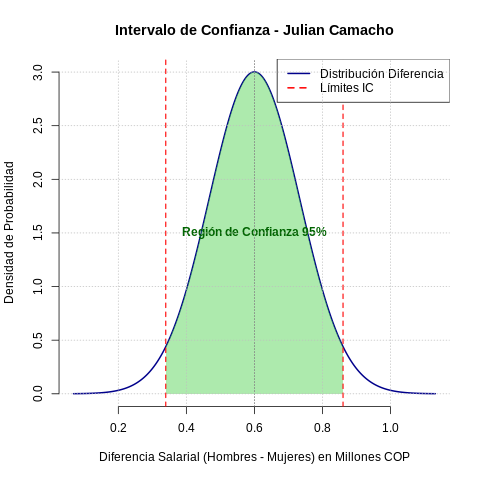

In [ ]:
# ---------------------------------------------------------
# Análisis de Brecha Salarial - Julian Camacho
# ---------------------------------------------------------
%%R
# 1. Definición de parámetros
n_h <- 150
media_h <- 4.8
std_h <- 1.2

n_m <- 150
media_m <- 4.2
std_m <- 1.1

confianza <- 0.95
nombre_autor <- "Julian Camacho"

# 2. Cálculos Estadísticos
diff_muestral <- media_h - media_m

# Error estándar para muestras independientes (n > 30)
error_estandar <- sqrt((std_h^2 / n_h) + (std_m^2 / n_m))

# Valor crítico Z para 95% de confianza (bilateral)
alfa <- 1 - confianza
z_critico <- qnorm(1 - alfa/2)

# Límites del Intervalo de Confianza (IC)
margen_error <- z_critico * error_estandar
ic_inf <- diff_muestral - margen_error
ic_sup <- diff_muestral + margen_error

# 3. Mostrar resultados en consola
cat("------------------------------------------\n")
cat("RESULTADOS DEL ANÁLISIS\n")
cat("Autor:", nombre_autor, "\n")
cat("------------------------------------------\n")
cat("Diferencia de medias:", round(diff_muestral, 3), "\n")
cat("Error estándar:", round(error_estandar, 4), "\n")
cat("Intervalo de Confianza (95%): [", round(ic_inf, 3), ",", round(ic_sup, 3), "]\n")
cat("------------------------------------------\n")

# 4. Generación del Gráfico
# Definir rango del eje X (4 desviaciones estándar a los lados)
x <- seq(diff_muestral - 4*error_estandar, diff_muestral + 4*error_estandar, length=1000)
y <- dnorm(x, mean = diff_muestral, sd = error_estandar)

# Crear el lienzo del gráfico
plot(x, y, type="l", lwd=2, col="darkblue",
     main=paste("Intervalo de Confianza -", nombre_autor),
     xlab="Diferencia Salarial (Hombres - Mujeres) en Millones COP",
     ylab="Densidad de Probabilidad",
     axes=FALSE)
axis(1) # Eje X
axis(2) # Eje Y

# Sombrear la región del Intervalo de Confianza
x_area <- seq(ic_inf, ic_sup, length=200)
y_area <- dnorm(x_area, mean = diff_muestral, sd = error_estandar)
polygon(c(ic_inf, x_area, ic_sup), c(0, y_area, 0), col=rgb(0.2, 0.8, 0.2, 0.4), border=NA)

# Agregar líneas de los límites y la media
abline(v=c(ic_inf, ic_sup), col="red", lty=2, lwd=1.5)
abline(v=diff_muestral, col="black", lty=3)

# Etiquetas de texto sobre el gráfico
text(diff_muestral, max(y)*0.5, "Región de Confianza 95%", col="darkgreen", font=2)
legend("topright", legend=c("Distribución Diferencia", "Límites IC"),
       col=c("darkblue", "red"), lty=c(1, 2), lwd=2)

grid(nx = NULL, ny = NULL, col = "gray", lty = "dotted")

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Contexto 2: Evaluación de impacto de programa social**


Análisis para: Julian Camacho
Diferencia: 70 | Margen de Error: 45.73
Intervalo 99%: (70 ± 45.7)


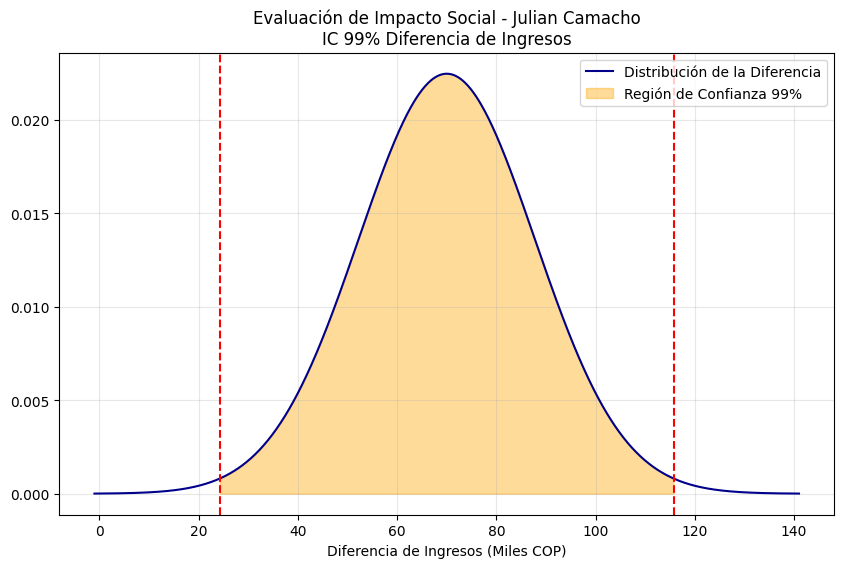

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos del problema
n_b, media_b, std_b = 200, 850, 180
n_nb, media_nb, std_nb = 200, 780, 175
confianza = 0.99
nombre = "Julian Camacho"

# Cálculos
diff_m = media_b - media_nb
error_est = np.sqrt((std_b**2 / n_b) + (std_nb**2 / n_nb))
z_critico = norm.ppf(1 - (1 - confianza) / 2)
margen_error = z_critico * error_est

ic_inf, ic_sup = diff_m - margen_error, diff_m + margen_error

print(f"Análisis para: {nombre}")
print(f"Diferencia: {diff_m} | Margen de Error: {margen_error:.2f}")
print(f"Intervalo 99%: ({diff_m} ± {margen_error:.1f})")

# Gráfico
x = np.linspace(diff_m - 4*error_est, diff_m + 4*error_est, 1000)
y = norm.pdf(x, diff_m, error_est)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Distribución de la Diferencia', color='darkblue')
plt.fill_between(x, y, where=(x >= ic_inf) & (x <= ic_sup), color='orange', alpha=0.4, label='Región de Confianza 99%')
plt.axvline(ic_inf, color='red', linestyle='--')
plt.axvline(ic_sup, color='red', linestyle='--')
plt.title(f'Evaluación de Impacto Social - {nombre}\nIC 99% Diferencia de Ingresos')
plt.xlabel('Diferencia de Ingresos (Miles COP)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Analista: Julian Camacho 
Diferencia Puntual: 70 
Margen de Error (99%): 45.73 
Intervalo: ( 70 +/- 45.7 )


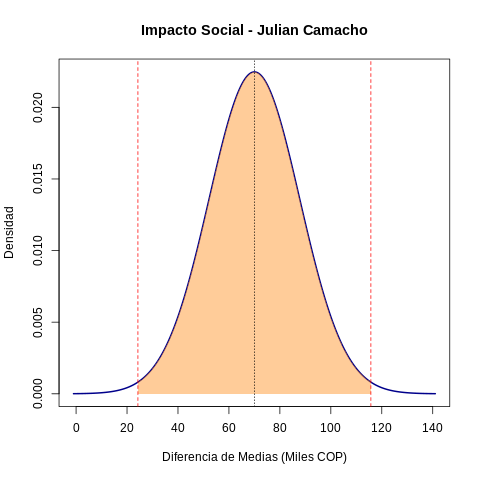

In [ ]:
%%R
# Parámetros
n_b <- 200; m_b <- 850; s_b <- 180
n_nb <- 200; m_nb <- 780; s_nb <- 175
conf <- 0.99
nombre <- "Julian Camacho"

# Cálculos
diff_m <- m_b - m_nb
ee <- sqrt((s_b^2/n_b) + (s_nb^2/n_nb))
z <- qnorm(1 - (1 - conf)/2)
margen <- z * ee
ic <- c(diff_m - margen, diff_m + margen)

# Consola
cat("Analista:", nombre, "\n")
cat("Diferencia Puntual:", diff_m, "\n")
cat("Margen de Error (99%):", round(margen, 2), "\n")
cat("Intervalo: (", diff_m, "+/-", round(margen, 1), ")\n")

# Gráfico
x <- seq(diff_m - 4*ee, diff_m + 4*ee, length=1000)
y <- dnorm(x, diff_m, ee)

plot(x, y, type="l", col="darkblue", lwd=2,
     main=paste("Impacto Social -", nombre),
     xlab="Diferencia de Medias (Miles COP)", ylab="Densidad")

x_area <- seq(ic[1], ic[2], length=200)
y_area <- dnorm(x_area, diff_m, ee)
polygon(c(ic[1], x_area, ic[2]), c(0, y_area, 0), col=rgb(1, 0.5, 0, 0.4), border=NA)
abline(v = ic, col="red", lty=2)
abline(v = diff_m, col="black", lty=3)

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Contexto 3: Comparación de metodologías educativas**


--- Análisis: Julian Camacho ---
Valor Crítico t(0.05, 20): 1.725
Varianza Combinada (Sp2): 0.310
Intervalo 90%: 0.50 ± 0.41


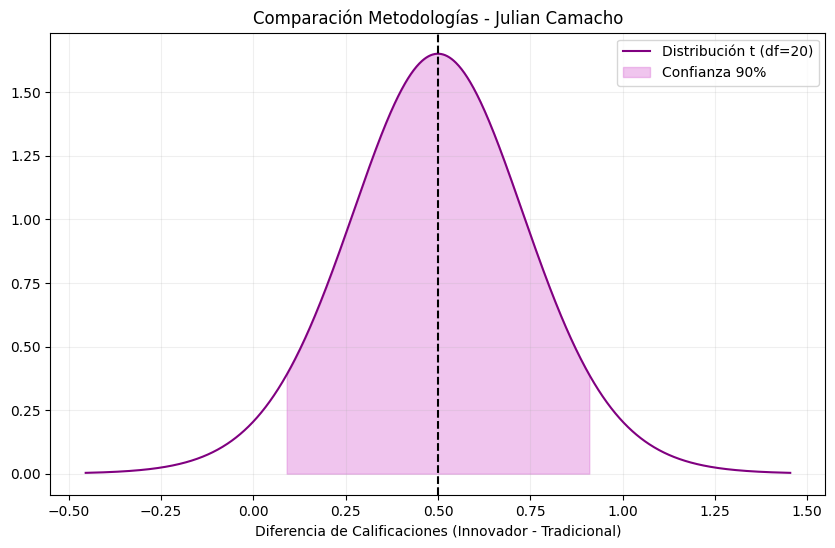

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Datos del problema
n_t, media_t, std_t = 12, 3.8, 0.6  # Tradicional
n_i, media_i, std_i = 10, 4.3, 0.5  # Innovador
confianza = 0.90
nombre = "Julian Camacho"

# 1. Grados de libertad y Valor Crítico (Pregunta 5)
df = n_t + n_i - 2
alpha = 1 - confianza
t_critico = t.ppf(1 - alpha/2, df)

# 2. Varianza Combinada Sp^2 (Pregunta 7)
sp2 = ((n_t - 1) * std_t**2 + (n_i - 1) * std_i**2) / df

# 3. Intervalo de Confianza (Pregunta 6)
diff_m = media_i - media_t
error_est_comb = np.sqrt(sp2 * (1/n_t + 1/n_i))
margen_error = t_critico * error_est_comb

print(f"--- Análisis: {nombre} ---")
print(f"Valor Crítico t(0.05, {df}): {t_critico:.3f}")
print(f"Varianza Combinada (Sp2): {sp2:.3f}")
print(f"Intervalo 90%: {diff_m:.2f} ± {margen_error:.2f}")

# Gráfico
x = np.linspace(diff_m - 4*error_est_comb, diff_m + 4*error_est_comb, 1000)
y = t.pdf(x, df, diff_m, error_est_comb)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'Distribución t (df={df})', color='purple')
plt.fill_between(x, y, where=((x >= diff_m - margen_error) & (x <= diff_m + margen_error)),
                 color='orchid', alpha=0.4, label='Confianza 90%')
plt.title(f'Comparación Metodologías - {nombre}')
plt.xlabel('Diferencia de Calificaciones (Innovador - Tradicional)')
plt.axvline(diff_m, color='black', linestyle='--')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Analista: Julian Camacho 
Valor t crítico: 1.725 
Varianza Combinada Sp2: 0.31 
Intervalo: ( 0.5 +/- 0.41 )


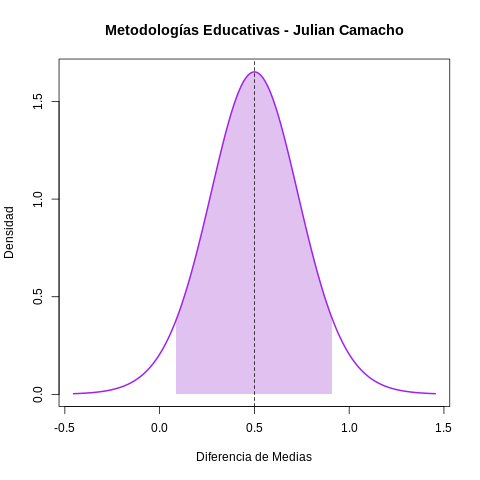

In [ ]:
%%R
# Datos
n_t <- 12; m_t <- 3.8; s_t <- 0.6
n_i <- 10; m_i <- 4.3; s_i <- 0.5
conf <- 0.90
nombre <- "Julian Camacho"

# Cálculos
df <- n_t + n_i - 2
t_crit <- qt(1 - (1 - conf)/2, df)

# Varianza Combinada (Sp2)
sp2 <- ((n_t - 1)*s_t^2 + (n_i - 1)*s_i^2) / df

# Intervalo
diff_m <- m_i - m_t
ee_comb <- sqrt(sp2 * (1/n_t + 1/n_i))
margen <- t_crit * ee_comb

# Resultados
cat("Analista:", nombre, "\n")
cat("Valor t crítico:", round(t_crit, 3), "\n")
cat("Varianza Combinada Sp2:", round(sp2, 3), "\n")
cat("Intervalo: (", diff_m, "+/-", round(margen, 2), ")\n")

# Gráfico
x <- seq(diff_m - 4*ee_comb, diff_m + 4*ee_comb, length=1000)
y <- dt((x - diff_m)/ee_comb, df) / ee_comb

plot(x, y, type="l", col="purple", lwd=2,
     main=paste("Metodologías Educativas -", nombre),
     xlab="Diferencia de Medias", ylab="Densidad")
x_area <- seq(diff_m - margen, diff_m + margen, length=200)
y_area <- dt((x_area - diff_m)/ee_comb, df) / ee_comb
polygon(c(diff_m - margen, x_area, diff_m + margen), c(0, y_area, 0), col=rgb(0.6, 0.2, 0.8, 0.3), border=NA)
abline(v = diff_m, lty=2)

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Contexto 4: Efecto de una campaña de salud pública**


--- Análisis: Julian Camacho ---
Grados de libertad (df): 26
Diferencia de medias: 2.30
Intervalo de Confianza (95%): 2.30 ± 2.25


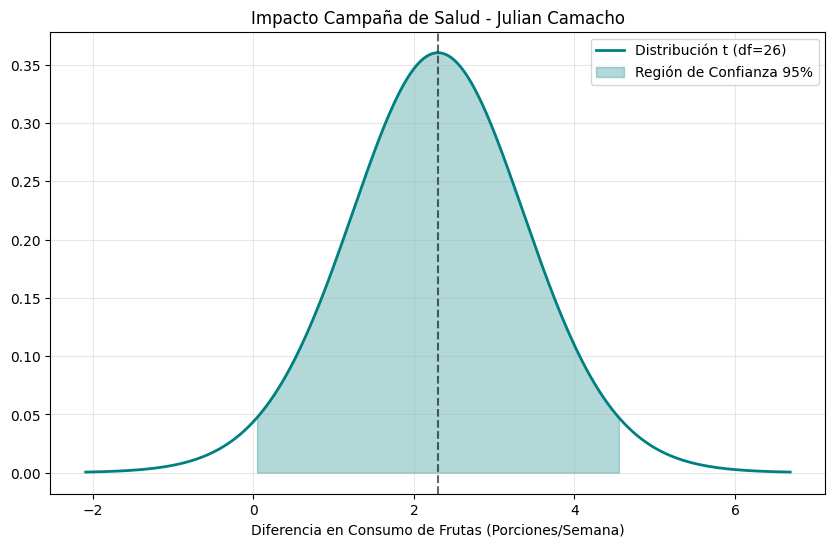

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Datos del Contexto 4
n_a, media_a, std_a = 15, 12.5, 2.8  # Intervención
n_b, media_b, std_b = 13, 10.2, 3.0  # Control
confianza = 0.95
nombre = "Julian Camacho"

# 1. Grados de libertad (Pregunta 8)
gl = n_a + n_b - 2

# 2. Cálculos adicionales para el intervalo
alpha = 1 - confianza
t_critico = t.ppf(1 - alpha/2, gl)
sp2 = ((n_a - 1) * std_a**2 + (n_b - 1) * std_b**2) / gl
diff_m = media_a - media_b
error_est = np.sqrt(sp2 * (1/n_a + 1/n_b))
margen = t_critico * error_est

print(f"--- Análisis: {nombre} ---")
print(f"Grados de libertad (df): {gl}")
print(f"Diferencia de medias: {diff_m:.2f}")
print(f"Intervalo de Confianza (95%): {diff_m:.2f} ± {margen:.2f}")

# 3. Gráfico
x = np.linspace(diff_m - 4*error_est, diff_m + 4*error_est, 1000)
y = t.pdf(x, gl, diff_m, error_est)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='teal', lw=2, label=f'Distribución t (df={gl})')
plt.fill_between(x, y, where=((x >= diff_m - margen) & (x <= diff_m + margen)),
                 color='teal', alpha=0.3, label='Región de Confianza 95%')
plt.axvline(diff_m, color='black', linestyle='--', alpha=0.6)
plt.title(f'Impacto Campaña de Salud - {nombre}')
plt.xlabel('Diferencia en Consumo de Frutas (Porciones/Semana)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

------------------------------------------
Autor: Julian Camacho 
Grados de Libertad (df): 26 
Diferencia observada: 2.3 
Margen de Error (95%): 2.25 
------------------------------------------


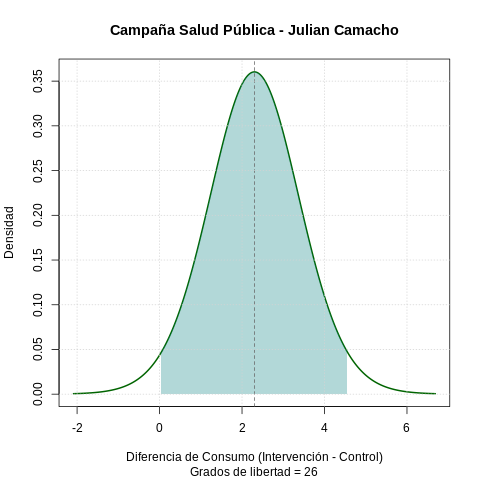

In [ ]:
%%R
# Parámetros del problema
n_a <- 15; m_a <- 12.5; s_a <- 2.8
n_b <- 13; m_b <- 10.2; s_b <- 3.0
nombre <- "Julian Camacho"

# 1. Grados de libertad (Pregunta 8)
df_val <- n_a + n_b - 2

# 2. Cálculos Estadísticos
sp2 <- ((n_a - 1)*s_a^2 + (n_b - 1)*s_b^2) / df_val
diff_m <- m_a - m_b
ee_comb <- sqrt(sp2 * (1/n_a + 1/n_b))
t_crit <- qt(0.975, df_val) # 95% confianza
margen <- t_crit * ee_comb

# Salida en Consola
cat("------------------------------------------\n")
cat("Autor:", nombre, "\n")
cat("Grados de Libertad (df):", df_val, "\n")
cat("Diferencia observada:", diff_m, "\n")
cat("Margen de Error (95%):", round(margen, 2), "\n")
cat("------------------------------------------\n")

# 3. Gráfico
x <- seq(diff_m - 4*ee_comb, diff_m + 4*ee_comb, length=1000)
y <- dt((x - diff_m)/ee_comb, df_val) / ee_comb

plot(x, y, type="l", col="darkgreen", lwd=2,
     main=paste("Campaña Salud Pública -", nombre),
     sub=paste("Grados de libertad =", df_val),
     xlab="Diferencia de Consumo (Intervención - Control)", ylab="Densidad")

# Sombreado de la región
x_area <- seq(diff_m - margen, diff_m + margen, length=200)
y_area <- dt((x_area - diff_m)/ee_comb, df_val) / ee_comb
polygon(c(diff_m - margen, x_area, diff_m + margen), c(0, y_area, 0), col=rgb(0, 0.5, 0.5, 0.3), border=NA)

abline(v = diff_m, lty=2, col="gray40")
grid()

[⬆️ Volver al inicio](#inicio)

<a name="T51"></a>
## **5. Contexto 5: Intención de voto en dos ciudades**




--- Análisis: Julian Camacho ---
Proporciones: Bogotá=0.55, Medellín=0.50
Error Estándar: 0.0335
Intervalo 95%: 0.05 ± 0.066


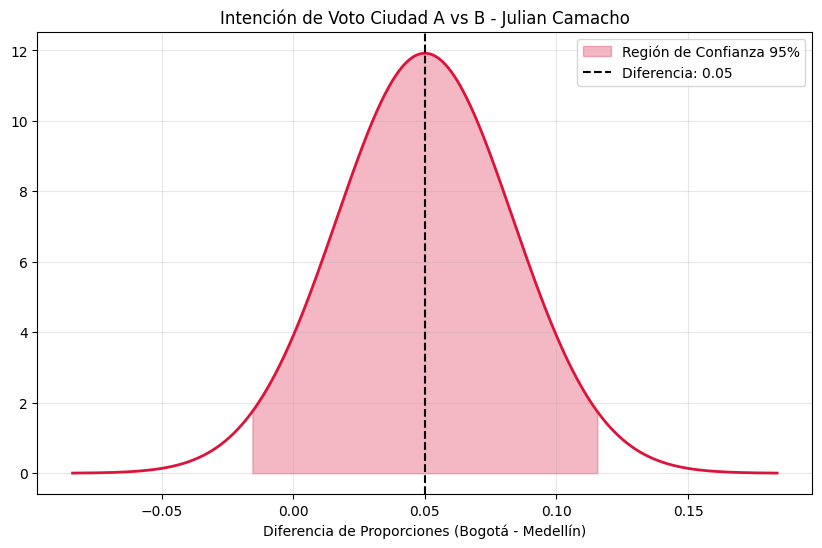

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Datos
n_b, x_b = 500, 275
n_m, x_m = 400, 200
confianza = 0.95
nombre = "Julian Camacho"

# Proporciones
p_b = x_b / n_b
p_m = x_m / n_m
diff_p = p_b - p_m

# Error Estándar
ee = np.sqrt((p_b * (1 - p_b) / n_b) + (p_m * (1 - p_m) / n_m))

# Margen de error y IC
z_critico = norm.ppf(1 - (1 - confianza) / 2)
margen = z_critico * ee
ic_inf, ic_sup = diff_p - margen, diff_p + margen

print(f"--- Análisis: {nombre} ---")
print(f"Proporciones: Bogotá={p_b:.2f}, Medellín={p_m:.2f}")
print(f"Error Estándar: {ee:.4f}")
print(f"Intervalo 95%: {diff_p:.2f} ± {margen:.3f}")

# Gráfico
x = np.linspace(diff_p - 4*ee, diff_p + 4*ee, 1000)
y = norm.pdf(x, diff_p, ee)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='crimson', lw=2)
plt.fill_between(x, y, where=((x >= ic_inf) & (x <= ic_sup)),
                 color='crimson', alpha=0.3, label='Región de Confianza 95%')
plt.axvline(diff_p, color='black', linestyle='--', label=f'Diferencia: {diff_p:.2f}')
plt.title(f'Intención de Voto Ciudad A vs B - {nombre}')
plt.xlabel('Diferencia de Proporciones (Bogotá - Medellín)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

------------------------------------------
Autor: Julian Camacho 
Proporción Bogotá: 0.55 | Proporción Medellín: 0.5 
Error estándar: 0.0335 
Intervalo de Confianza: ( 0.05 +/- 0.066 )
------------------------------------------


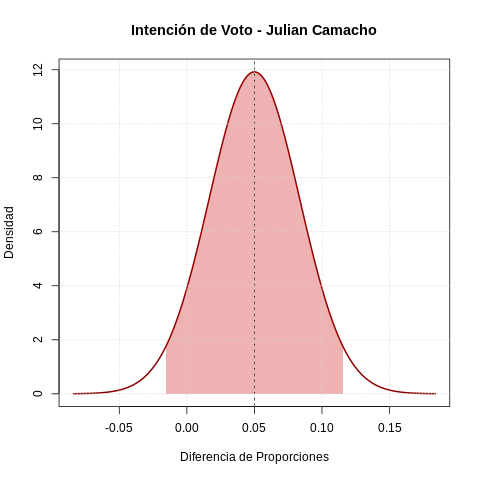

In [ ]:
%%R
# Parámetros
n_b <- 500; x_b <- 275
n_m <- 400; x_m <- 200
nombre <- "Julian Camacho"

# Cálculos
p_b <- x_b / n_b
p_m <- x_m / n_m
diff_p <- p_b - p_m

# Error estándar
ee <- sqrt((p_b*(1-p_b)/n_b) + (p_m*(1-p_m)/n_m))

# Margen al 95%
z_crit <- qnorm(0.975)
margen <- z_crit * ee
ic <- c(diff_p - margen, diff_p + margen)

# Consola
cat("------------------------------------------\n")
cat("Autor:", nombre, "\n")
cat("Proporción Bogotá:", p_b, "| Proporción Medellín:", p_m, "\n")
cat("Error estándar:", round(ee, 4), "\n")
cat("Intervalo de Confianza: (", round(diff_p, 2), "+/-", round(margen, 3), ")\n")
cat("------------------------------------------\n")

# Gráfico
x_vals <- seq(diff_p - 4*ee, diff_p + 4*ee, length=1000)
y_vals <- dnorm(x_vals, diff_p, ee)

plot(x_vals, y_vals, type="l", col="darkred", lwd=2,
     main=paste("Intención de Voto -", nombre),
     xlab="Diferencia de Proporciones", ylab="Densidad")

x_area <- seq(ic[1], ic[2], length=200)
y_area <- dnorm(x_area, diff_p, ee)
polygon(c(ic[1], x_area, ic[2]), c(0, y_area, 0), col=rgb(0.8, 0, 0, 0.3), border=NA)

abline(v = diff_p, lty=2)
grid()

[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Contexto 6: Control de calidad en producción agrícola**


--- Análisis: Julian Camacho ---
Grados de libertad: 19
Valores críticos Chi2: 10.12 y 30.14
Intervalo 90% para la varianza: (15.76, 46.95)


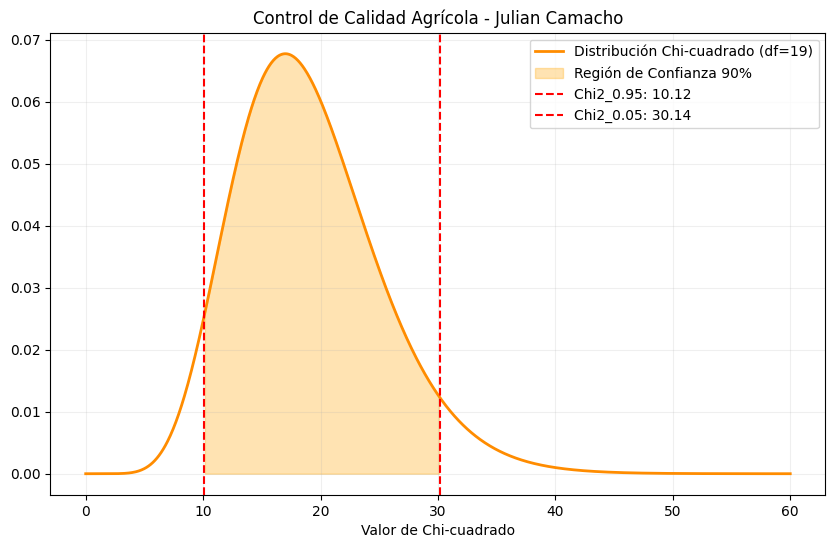

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Datos
n = 20
varianza_muestral = 25
confianza = 0.90
nombre = "Julian Camacho"

# Grados de libertad y valores críticos
df = n - 1
alpha = 1 - confianza
chi2_inf = chi2.ppf(alpha / 2, df)     # Valor crítico inferior (0.05)
chi2_sup = chi2.ppf(1 - alpha / 2, df) # Valor crítico superior (0.95)

# Intervalo de Confianza para la Varianza
ic_inf = (df * varianza_muestral) / chi2_sup
ic_sup = (df * varianza_muestral) / chi2_inf

print(f"--- Análisis: {nombre} ---")
print(f"Grados de libertad: {df}")
print(f"Valores críticos Chi2: {chi2_inf:.2f} y {chi2_sup:.2f}")
print(f"Intervalo 90% para la varianza: ({ic_inf:.2f}, {ic_sup:.2f})")

# Gráfico de la distribución Chi-cuadrado
x = np.linspace(0, 60, 1000)
y = chi2.pdf(x, df)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='darkorange', lw=2, label=f'Distribución Chi-cuadrado (df={df})')
plt.fill_between(x, y, where=((x >= chi2_inf) & (x <= chi2_sup)),
                 color='orange', alpha=0.3, label='Región de Confianza 90%')
plt.axvline(chi2_inf, color='red', linestyle='--', label=f'Chi2_0.95: {chi2_inf:.2f}')
plt.axvline(chi2_sup, color='red', linestyle='--', label=f'Chi2_0.05: {chi2_sup:.2f}')
plt.title(f'Control de Calidad Agrícola - {nombre}')
plt.xlabel('Valor de Chi-cuadrado')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

------------------------------------------
Autor: Julian Camacho 
Grados de Libertad: 19 
Valores Críticos Chi2: 10.12 y 30.14 
Intervalo de Confianza para Varianza: [ 15.76 , 46.95 ]
------------------------------------------


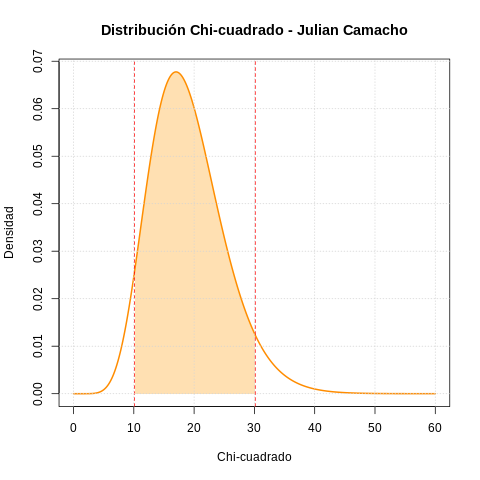

In [ ]:
%%R
# Parámetros del ejercicio
n <- 20
s2 <- 25
confianza <- 0.90
nombre <- "Julian Camacho"

# Grados de libertad
df <- n - 1

# Valores Críticos (Notación R: qchi2 usa el área a la izquierda)
# Para alfa/2 = 0.05 en la cola derecha, el área a la izq es 0.95
chi2_derecho <- qchisq(0.95, df)
chi2_izquierdo <- qchisq(0.05, df)

# Límites del intervalo
ic_inf <- (df * s2) / chi2_derecho
ic_sup <- (df * s2) / chi2_izquierdo

# Consola
cat("------------------------------------------\n")
cat("Autor:", nombre, "\n")
cat("Grados de Libertad:", df, "\n")
cat("Valores Críticos Chi2:", round(chi2_izquierdo, 2), "y", round(chi2_derecho, 2), "\n")
cat("Intervalo de Confianza para Varianza: [", round(ic_inf, 2), ",", round(ic_sup, 2), "]\n")
cat("------------------------------------------\n")

# Gráfico
x_vals <- seq(0, 60, length=1000)
y_vals <- dchisq(x_vals, df)

plot(x_vals, y_vals, type="l", col="darkorange", lwd=2,
     main=paste("Distribución Chi-cuadrado -", nombre),
     xlab="Chi-cuadrado", ylab="Densidad")

# Sombreado de la zona de confianza
x_area <- seq(chi2_izquierdo, chi2_derecho, length=200)
y_area <- dchisq(x_area, df)
polygon(c(chi2_izquierdo, x_area, chi2_derecho), c(0, y_area, 0),
        col=rgb(1, 0.6, 0, 0.3), border=NA)

abline(v = c(chi2_izquierdo, chi2_derecho), col="red", lty=2)
grid()

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. Contexto 7: Comparación de volatilidad en mercados financieros**




--- Análisis Financiero: Julian Camacho ---
Estadístico F: 2.333
Grados de libertad: (24, 19)
Intervalo 95% (Cociente σ1²/σ2²): (0.95, 5.47)


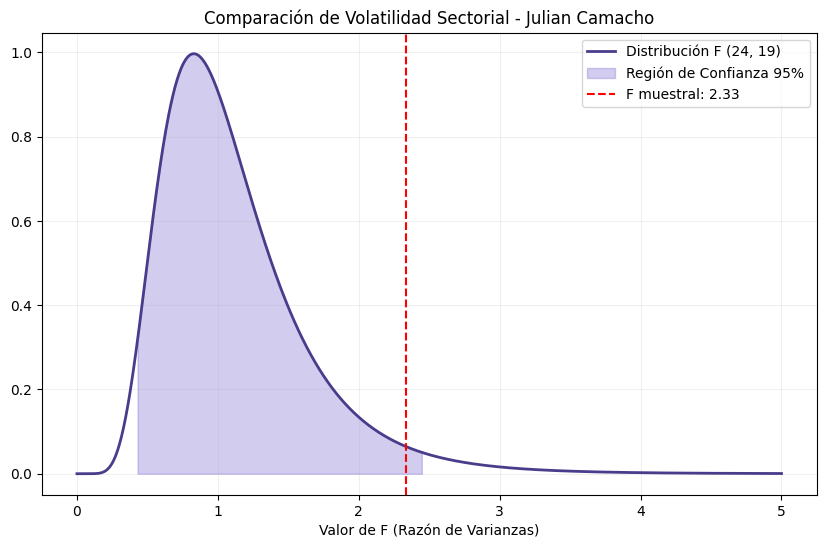

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Datos del Contexto 7
n1, s2_1 = 25, 0.042
n2, s2_2 = 20, 0.018
confianza = 0.95
nombre = "Julian Camacho"

# Grados de libertad
df1, df2 = n1 - 1, n2 - 1

# Estadístico F
f_muestral = s2_1 / s2_2

# Valores críticos
alpha = 1 - confianza
f_crit_inf = f.ppf(alpha / 2, df1, df2)
f_crit_sup = f.ppf(1 - alpha / 2, df1, df2)

# Límites del intervalo para el cociente de varianzas
ic_inf = f_muestral / f.ppf(1 - alpha / 2, df1, df2)
ic_sup = f_muestral / f.ppf(alpha / 2, df1, df2)

print(f"--- Análisis Financiero: {nombre} ---")
print(f"Estadístico F: {f_muestral:.3f}")
print(f"Grados de libertad: ({df1}, {df2})")
print(f"Intervalo 95% (Cociente σ1²/σ2²): ({ic_inf:.2f}, {ic_sup:.2f})")

# Gráfico de la distribución F
x = np.linspace(0, 5, 1000)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='darkslateblue', lw=2, label=f'Distribución F ({df1}, {df2})')
plt.fill_between(x, y, where=((x >= f_crit_inf) & (x <= f_crit_sup)),
                 color='slateblue', alpha=0.3, label='Región de Confianza 95%')
plt.axvline(f_muestral, color='red', linestyle='--', label=f'F muestral: {f_muestral:.2f}')
plt.title(f'Comparación de Volatilidad Sectorial - {nombre}')
plt.xlabel('Valor de F (Razón de Varianzas)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

------------------------------------------
Autor: Julian Camacho 
Estadístico F: 2.333 
Grados de libertad: df1 = 24 , df2 = 19 
Intervalo de Confianza (95%): [ 0.95 , 5.47 ]
------------------------------------------


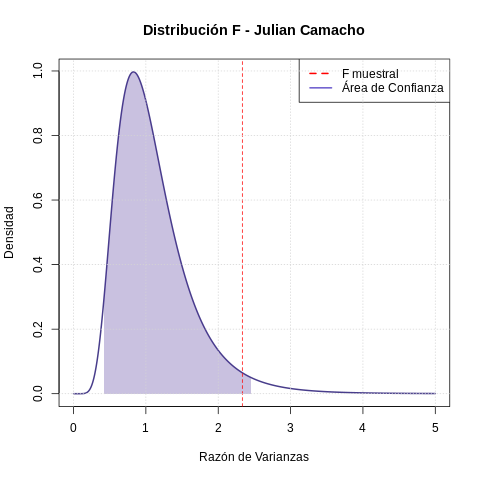

In [ ]:
%%R
# Parámetros del ejercicio
n1 <- 25; s2_1 <- 0.042
n2 <- 20; s2_2 <- 0.018
nombre <- "Julian Camacho"

# Grados de libertad
df1 <- n1 - 1
df2 <- n2 - 1

# Estadístico F
f_muestral <- s2_1 / s2_2

# Valores críticos para el 95% de confianza
f_crit_low <- qf(0.025, df1, df2)
f_crit_high <- qf(0.975, df1, df2)

# Intervalo de confianza
ic_inf <- f_muestral / f_crit_high
ic_sup <- f_muestral / f_crit_low

# Consola
cat("------------------------------------------\n")
cat("Autor:", nombre, "\n")
cat("Estadístico F:", round(f_muestral, 3), "\n")
cat("Grados de libertad: df1 =", df1, ", df2 =", df2, "\n")
cat("Intervalo de Confianza (95%): [", round(ic_inf, 2), ",", round(ic_sup, 2), "]\n")
cat("------------------------------------------\n")

# Gráfico
x_vals <- seq(0, 5, length=1000)
y_vals <- df(x_vals, df1, df2)

plot(x_vals, y_vals, type="l", col="darkslateblue", lwd=2,
     main=paste("Distribución F -", nombre),
     xlab="Razón de Varianzas", ylab="Densidad")

# Sombreado
x_area <- seq(f_crit_low, f_crit_high, length=200)
y_area <- df(x_area, df1, df2)
polygon(c(f_crit_low, x_area, f_crit_high), c(0, y_area, 0),
        col=rgb(0.3, 0.2, 0.6, 0.3), border=NA)

abline(v = f_muestral, col="red", lty=2)
legend("topright", legend=c("F muestral", "Área de Confianza"),
       col=c("red", "slateblue"), lty=c(2, 1), lwd=2)
grid()

[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO